# Machine Learning 2025/26 - Second delivery

Ana Rita Dias 20250480<br>
Catarina Santos 20250501<br>
Marisa Ramos 20250521<br>
Nadia Scaletchi 20250404

# Summary
This project focuses on developing a robust regression system to predict used car prices based on vehicle characteristics. From a business perspective, accurate `price` estimation is essential for supporting decision-making in the used car market, helping sellers and dealers define competitive prices while reducing uncertainty before mechanical inspection. The primary goal was to identify a high performing machine learning model capable of accurately estimating a vehicle’s `price` prior to inspection. The work followed a structured pipeline combining __data preprocessing__, __feature engineering__, __model experimentation__, and __performance evaluation__.

Data preprocessing played a central role and included handling numerical __missing values__ using mean or median imputation, resolving categorical inconsistencies through manually defined dictionaries, and reducing the influence of extreme __outliers__ via Winsorizing. Feature engineering was applied to improve predictive power and model interpretability, leading to the creation of variables such as `carAge` and `AvgMileagePerYear`. Numerical features were normalized using __MinMaxScaler__ to ensure fair model comparison.

A wide range of __regression models__ was explored. __Neural Networks__ were carefully tuned, with the best configuration consisting of two __hidden layers__ (100 and 50 neurons), a maximum of 1000 iterations, and a __batch size__ of 128. __Decision Tree__ models were also evaluated using both __Mean Squared Error__ ($MSE$) and __Mean Absolute Error__ ($MAE$) as splitting criteria, with MSE demonstrating superior performance. __Ensemble learning methods__ were then implemented, including __Bagging__, __Gradient Boosting__, and __Random Forest__ models.

After comparing all approaches using test-set performance metrics, the __Random Forest model__ (__rf_model__) emerged as the best-performing solution, achieving the lowest prediction error and demonstrating strong robustness to nonlinear relationships. From a business standpoint, this model provides a reliable tool for supporting pricing strategies and improving confidence in valuation decisions.

# Table of content

1. [Previous notebook](#previous-notebook)
    - [Preprocessing, Feature Selection & Modeling Strategy](#preprocessing-feature-selection--modeling-strategy)
2. [Importing library](#importing-library)
3. [Importing the processed data](#importing-the-preprocessed-data)
4. [K-nearest neighbor regression- Knn-regression](#1-k-nearest-neighbor-regression-knn-regression)
    - [Methods in k-neighborsregressor](#11-methods-in-kneighborsregressor)
        - [Using the .fit() method](#111-using-the-fitmethod)
        - [Using the .predict() method](#112-using-the-predict-method)
        - [Using the .score()](#113-using-the-score)
    - [Optimal number of neighbors to select](#12-optimal-number-of-neighbors-to-select)
5. [Neural networks - MLPregressor](#2-neural-networks-mlpregressor)
    - [Multi-layer perceptron regressor - MLPregressor](#21-multi-layer-perceptron-regressor-mlpregressor)
        - [Methods in MLPRegressor](#211-methods-in-mlpregressor)
    - [Activation function](#22-activation-function)
    - [Hidden layers](#23-hidden-layers)
        - [MLPRegressor with 1 hidden layer and 50 neurons](#231-mlpregressor-with-1-hidden-layer-and-50-neurons)
        - [MLPRegressor with 1 hidden layers and 100 neurons](#232-mlpregressor-with-1-hidden-layers-and-100-neurons)
        - [MLPRegressor with 2 hidden layers with 50 neurons each layer](#233-mlpregressor-with-2-hidden-layers-with-50-neurons-each-layer)
        - [MLPRegressor with 2 hidden layers (100, 50)](#234-mlpregressor-with-2-hidden-layers-first-layer-with-100-neurons-and-the-second-layer-with-50-neurons)
        - [MLPRegressor with 2 hidden layers (100, 100)](#235-mlpregressor-with-2-hidden-layers-with-100-neurons-each-layer)
        - [Checking mean accuracy of each model](#236-checking-the-mean-accuracy-of-each-model-by-calling-the-function-show_results-and-pass-as-arguments-the-dataset-and-the-three-models)
        - [Loss curve](#237-loss-curve)
    - [Maximum iterations](#24-maximum-iterations)
        - [Instance with max_iter = 20](#241-creating-an-instance-of-mlpregressor-with-max_iter--20-and-the-hidden_layer_size10050)
        - [Instance with max_iter = 200](#242-creating-an-instance-of-mlpregressor-with-max_iter--200-and-the-hidden_layer_size10050)
        - [Instance with max_iter = 1000](#243-creating-an-instance-of-mlpregressor-with-max_iter--1000-and-the-hidden_layer_size10050)
    - [Batch size](#25-batch-size)
        - [Batch size = 32](#251-creating-an-instance-of-mlpregressor-with-hidden_layer_size10050-and-batch_size--32)
        - [Batch size = 64](#252-creating-an-instance-of-mlpregressor-with-hidden_layer_size10050-and-batch_size--64)
        - [Batch size = 128](#253-creating-an-instance-of-mlpregressor-with-max_iter--200-hidden_layer_size10050-and-batch_size--128)
6. [Decision trees for regression](#3-decision-trees-for-regression)
    - [Using fit method](#31-using-fit-method)
    - [Inspect depth nodes leaves and measure trainvalidation performance](#32-inspect-depth-nodes-leaves-and-measure-trainvalidation-performance)
    - [Changing the splitting criteria](#34-changing-the-splitting-criteria)
        - [Evaluate feature importance](#341-use-a-decision-tree-to-evaluate-feature-importance)
    - [Minimal Cost-Complexity Pruning](#36-minimal-cost-complexity-pruning-for-regression)
        - [Choose the complexity parameter](#361-choose-the-complexity-parameter)
7. [Ensemble methods](#4-ensemble-methods)
    - [Bagging regressor](#41-bagging-regressor)
    - [Random forest regressor](#42-random-forest-regressor)
    - [Gradient boosting regressor](#43-gradient-boosting-regressor)
    - [Checking the mean accuracy of ensemble models](#44-checking-the-mean-accuracy-of-each-model-by-calling-the-function-show_results-and-pass-as-arguments-the-dataset-and-the-three-models)
8. [Summary of results / Model decision](#5-summary-of-results)
    - [Neural networks models](#neural-networks-models)
    - [Decision trees](#decission-trees)
    - [Ensemble models](#ensemble-models)
9. [Open-ended](#6-open-ended)
    - [Segmented Error Analysis and Market Dynamics](#61-segmented-error-analysis-and-market-dynamics)
        - [Data Segmentation](#611-data-segmentation)
        - [Descriptive Statistics](#612-descriptive-statistics)
        - [Segments Metrics](#613-segments-metrics)
        - [Features Importance](#614-features-importance)
10. [Dashboard of an Input Prediction](#7-dashboard-of-an-input-prediction)

# Previous notebook
### Preprocessing, Feature Selection & Modeling Strategy

In the previous notebook, extensive cleaning and data preparation were performed to ensure quality inputs for the regression `model`. The focus was on correcting inconsistencies, handling missing values without losing too much information, and creating new features relevant to price prediction. 

Here is a quick review of the changes made to the data:

__0. Splitting the data__

* First it's important to mention that, before doing any steps, we splitted the `train_data` given with the function `train_test_split` into trainning(70%) and validation (30%) validation set (with the target separated from the rest).

__1. Data Cleaning & Consistency__

* For missing values (NaN) in numerical variables, we analyzed the distribution and decided to procede with different methods: Using the mean for the features that didn't had significant outliers and the median for the other variables.

* For categorical variables, missing values were filled with the category "__Unknown__", excluding the binary variable (`hasDamage`) that was filled with '0'.

* We confirmed that the `carID` column had no duplicates and served only as an identifier, so it was dropped as it adds no predictive value. 

* It was detected a high percentage of outliers. Instead of removing the rows, which would cause massive data loss, we applied __Capping (Winsorizing)__ between the 0.01 and 0.99 quantile, limiting extreme values to realistic intervals.

* For the categorical variables (`Brand`, `model`, `transmission`, `fuelType`) we identified syntactic inconsistencies. To solve them we used the `difflib` library and manual dictionaries to correct and normalize these errors.  

* We identified incorrect data types in the `year` and `previousOwners` features. They were floats and we converted them to integers.  

* The `hasDamage` column contained only the value "0" (zero variance), making it redundant, so it was dropped.

__2. Feature Engineering__  

* To start, we encoded the categorical features using `OneHotEncoder` so the computer could understand and use them to predict target values.

* We created the `carAge` variable based on the registration year (2025 - `year`), since age has a more linear relationship with `price` depreciation. Then we removed the original `year` variable to avoid redundancy. It was also created the `AvgMileagePerYear` variable to measure annual vehicle wear.  

* For the numerical variables it was necessary to scale them, using the `MinMaxScaller` estimator, to avoid certain features dominating the model due to ensure optimal performance convergence and accuracy.

* After preprocessing, we evaluated the importance of the variables and trained several __Linear Regression models__ in order to identify the best combination of features for predicting car prices.

__3. Feature Selection__ 

* To start on __filter methods__, we consider the following methods: __Univariate variables__, __Correlation indices__ (pearson and spearman), __Chi-square Test__, with the last one being for the categorical variables. In the __Spearman Correlation matrix__ we found a high multicollinearity between `carAge`, `mileage`and `AvgMileagePerYear`. Since `carAge` had a stronger correlation with the target (`price`), we initially considered dropping `mileage` and `AvgMileagePerYear`. The __Chi-Square test__ suggested dropping 128 categorical columns. However, we decided to keep them, as domain knowledge indicates that specific car `Brands` and `Models` are critical determinants of price, regardless of statistical independence tests.  

* For the __wrapper methods__ we utilized __RFE__ (Recursive Feature Elimination) witch suggested keeping 7 numerical features, only dropping `previousOwners`.

* Finally, in __embedded methods__, the __Lasso Regression__ retained all numerical features, except the feature `AvgMileagePerYear`.

__4. Model Selection__ 

* Here, interacted through for different models, varying the input features to optimize performace:

- __Model 1__: Removed `paintQuality%`, `previousOwners`, `AvgMileagePerYear`.  
- __Model 2__: Removed `paintQuality%`, `previousOwners`.   
- __Model 3__: Removed `paintQuality%`, `AvgMileagePerYear`.  
- __Model 4__: Removed `paintQuality%`.  

__6. Evaluation & Conclusions__  

We evaluated the models using __$R^2$__ (R-Squared), __RMSE__ (Root Mean Squared Error), and __MAE__ (Mean Absolute Error).  

The Best Model: Model .

- __$R^2$__: 0.7904 (Explains 79% of price variability).  
- __RMSE__: 4521.39 (Lowest error in currency units).
- __MAE__: 2687.54 (Lowest mean absolute error).

We successfully generated predictions for the test dataset, rounded the values to integers (as `prices` are whole numbers), and exported the results.

# Importing Library

In [1]:
#pip install pandas
#! pip install graphviz pydotplus
#! pip install tqdm
#!pip install ipywidgets
#!pip install --upgrade joblib scikit-learn
!pip install tqdm-joblib

In [2]:
# Standard Libraries
import time
import warnings
import difflib
from typing import List, Optional

# Data Handling Libraries
import numpy as np
import pandas as pd

np.random.seed(33)  # For reproducibility


# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
import pydotplus
from IPython.display import display
import ipywidgets as widgets

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
sns.set(style='whitegrid')


# Progress Bars
from tqdm import tqdm
from tqdm.notebook import tqdm 
from tqdm_joblib import tqdm_joblib


# Statistical and Feature Selection Tools
from scipy.stats import chi2_contingency  # Chi-squared test
import scipy.stats as stats  # spearman

from sklearn.feature_selection import mutual_info_classif  # Mutual information for classification
from sklearn.feature_selection import RFE


# Preprocessing
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler


# Model Selection and Cross-Validation
from sklearn.model_selection import (
    train_test_split,
    PredefinedSplit,
    cross_val_score,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    ParameterGrid
)
from joblib import Parallel, delayed, parallel_backend
import joblib


# Regression and Classification Models
from sklearn.linear_model import LogisticRegression, LinearRegression, LassoCV
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, BaggingRegressor
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn import tree
from sklearn.neural_network import MLPRegressor


# Model Evaluation
from sklearn.metrics import (
    f1_score,
    roc_curve,
    precision_recall_curve,
    mean_squared_error,
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error
)
from sklearn.inspection import permutation_importance


# Warnings
warnings.filterwarnings('ignore')

C:\Users\Marisa Ramos\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# Importing the preprocessed data

To start, the preprocessed data will be import with the changes of the previous notebook.

In [3]:
X_train = pd.read_csv("../Group_28/project_data/X_train.csv", sep=',')
X_val = pd.read_csv("../Group_28/project_data/X_val.csv", sep=',')
y_train = pd.read_csv("../Group_28/project_data/y_train.csv", sep=',')
y_val = pd.read_csv("../Group_28/project_data/y_val.csv", sep=',')
test_data =  pd.read_csv("../Group_28/project_data/test_data.csv", sep=',')

In [23]:
X_val.head()

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,...,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown,carAge,AvgMileagePerYear
0,0.000000,0.483333,0.245439,0.50,0.840580,0.00,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.909091,2.529126e-07
1,0.137152,0.066667,0.678275,0.30,0.347826,1.00,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.636364,1.366076e-01
2,0.102195,0.500000,0.553897,0.00,0.710145,1.00,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.818182,1.017392e-01
3,0.000072,0.483333,0.000000,0.25,0.492754,0.25,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.909091,7.186284e-05
4,0.158744,0.500000,0.512438,0.00,0.115942,0.50,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.818182,1.581149e-01


In [24]:
y_train.head()

,price
0,7995
1,12399
2,13998
3,7990
4,13990


In [25]:
y_val.head()

,price
0,27995
1,10298
2,10000
3,20985
4,12495


In [26]:
test_data.head()

,carID,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,carAge,AvgMileagePerYear,Brand_bmw,...,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown
0,89856,0.314517,0.683333,0.223881,0.30,0.449275,0.75,1.000000,3.128041e-01,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,106581,0.000000,0.500000,0.169154,0.50,0.434783,0.50,0.727273,1.515971e-07,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,80886,0.376949,0.416667,0.388060,0.25,0.927536,0.50,0.636364,3.756401e-01,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,100174,0.056601,0.483333,0.266998,0.10,0.681159,0.25,0.909091,5.632044e-02,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,81376,0.092726,0.500000,0.388060,0.50,0.217391,1.00,0.909091,9.226636e-02,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [27]:
X_train.describe()

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,...,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown,carAge,AvgMileagePerYear
count,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,...,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000,53181.000000
mean,0.234638,0.408566,0.442060,0.327310,0.501475,0.498467,0.099603,0.216506,0.044753,0.156033,...,0.000395,0.546661,0.222279,0.030048,0.000056,0.029127,0.542581,0.022395,0.736404,0.233843
std,0.210155,0.198387,0.186322,0.257337,0.292212,0.351811,0.299473,0.411867,0.206763,0.362890,...,0.019868,0.497823,0.415781,0.170722,0.007511,0.168164,0.498188,0.147966,0.184348,0.209640
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.078429,0.416667,0.316750,0.100000,0.246377,0.250000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.636364,0.078092
50%,0.177273,0.483333,0.436153,0.300000,0.501540,0.500000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.727273,0.176570
75%,0.327276,0.483333,0.553897,0.500000,0.753623,0.750000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.909091,0.326082
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [28]:
X_val.describe()

,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,Brand_bmw,Brand_ford,Brand_hyundai,Brand_mercedes,...,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown,carAge,AvgMileagePerYear
count,22792.000000,22792.000000,22792.000000,22792.000000,22792.000000,22792.000000,22792.000000,22792.000000,22792.000000,22792.000000,...,22792.000000,22792.000000,22792.000000,22792.000000,22792.000000,22792.00000,22792.000000,22792.000000,22792.000000,22792.000000
mean,0.235618,0.408985,0.442616,0.327774,0.501016,0.499704,0.098543,0.217883,0.044796,0.158213,...,0.000614,0.550851,0.221613,0.029177,0.000044,0.02966,0.540804,0.021367,0.735984,0.234674
std,0.212117,0.198207,0.185780,0.256980,0.294707,0.353588,0.298054,0.412817,0.206861,0.364949,...,0.024777,0.497418,0.415341,0.168306,0.006624,0.16965,0.498343,0.144608,0.186503,0.211268
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.076759,0.416667,0.326700,0.100000,0.246377,0.250000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.636364,0.076435
50%,0.177273,0.483333,0.436153,0.300000,0.501540,0.500000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.727273,0.176483
75%,0.331706,0.483333,0.553897,0.500000,0.753623,0.750000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000,0.909091,0.330137
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [29]:
y_train.describe()

,price
count,53181.000000
mean,16877.098249
std,9676.919334
min,450.000000
25%,10210.000000
50%,14699.000000
75%,20974.000000
max,149948.000000


In [30]:
y_val.describe()

,price
count,22792.000000
mean,16893.069191
std,9875.728913
min,675.000000
25%,10169.250000
50%,14695.000000
75%,20900.000000
max,159999.000000


In [31]:
test_data.describe()

,carID,mileage,tax,mpg,engineSize,paintQuality%,previousOwners,carAge,AvgMileagePerYear,Brand_bmw,...,model_z4,model_zafira,model_zafira tourer,transmission_manual,transmission_semi-auto,transmission_unknown,fuelType_electric,fuelType_hybrid,fuelType_petrol,fuelType_unknown
count,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,...,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000,32567.000000
mean,92256.000000,0.234550,0.409098,0.441849,0.330064,0.499482,0.501558,0.736398,0.233757,0.097461,...,0.000768,0.005896,0.000676,0.549298,0.223140,0.010686,0.000031,0.028741,0.537262,0.002518
std,9401.427445,0.210789,0.198143,0.187660,0.258119,0.293838,0.351626,0.185645,0.210274,0.296589,...,0.027696,0.076557,0.025983,0.497571,0.416358,0.102819,0.005541,0.167080,0.498617,0.050116
min,75973.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,84114.500000,0.076759,0.416667,0.316750,0.150000,0.246377,0.250000,0.636364,0.076379,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,92256.000000,0.177273,0.483333,0.436153,0.300000,0.501540,0.500000,0.727273,0.176483,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,100397.500000,0.328162,0.483333,0.553897,0.500000,0.753623,0.750000,0.909091,0.327093,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,108539.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 1. K-Nearest Neighbor Regression (KNN Regression)

**KNN Regressor** is a regression based on k-nearest neighbors. The target is predicted by local interpolation of the target values associated with the nearest neighbors in the training set.

**KNN Regression** predicts the target value by taking the **mean** or **weighted mean** of the K nearest neighbors' target value. 
As the objective of this project is to predict the `price` of the car before going to the mechanic, and it is a regression problem we will be using the **KNN Regresor**.

The differences between the **KNN Regressor** and the **KNN Classifier** are:

- **Output**: Continuous value instead of class label
- **Aggregation**: Mean/weighted mean instead of majority vote
- **Evaluation**: Use regression metrics ($MAE$, $MSE$, $R²$) instead of classification metrics (accuracy, F1)


Using KNeighborsRegressor, we create an instance called `modelKNN_Reg`.

In [32]:
modelKNN_Reg = KNeighborsRegressor()

## 1.1. Methods in KNeighborsRegressor

### 1.1.1 Using the `.fit()`method

We'll use the `.fit()` method to fit the model to the array of points `X_train` and `y_train`, associate the argument keyword `X` to `X_train` and `y` to `y_train`.

In [33]:
modelKNN_Reg.fit(X = X_train, y = y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


From the output above, by default, we can observe 5 neighbors considering a distance power of 2 (p 2) that means the euclidian distance.

### 1.1.2. Using the `.predict()` method

 We'll use the `.predict()` method to perform classification in `X_train` and assign to the object `labels_train`. Do the same for `X_val` and assign to the object `labels_val`.

In [34]:
labels_train = modelKNN_Reg.predict(X_train)
labels_val = modelKNN_Reg.predict(X_val)

### 1.1.3. Using the `.score()`

Using the `.score()` method to obtain the coefficient of determination $R^2$ of the given training data `X_train` and the true labels for X, `y_train`.  

And we will also use this method to obtain the coefficient of determination $R^2$ of the given test data `X_val` and the true labels for X, `y_val`.

In [35]:
print(modelKNN_Reg.score(X_train, y_train))
print(modelKNN_Reg.score(X_val, y_val))

0.9131971735321049
0.8569668072749075


Comparing the results we can conclude that the accuracy of the model is higher in the train dataset, so this is a case of overfitting.

In [36]:
print(mean_absolute_error(y_train, labels_train))
print(mean_absolute_error(y_val, labels_val))

1645.8402813034734
2047.9399613899614


In [37]:
print(mean_squared_error(y_train, labels_train))
print(mean_squared_error(y_val, labels_val))

8128304.077907523
13949418.311702352


The two outputs above are using another metrics to evaluate __Regression models__.<br>
In this case we can confirm that the __MAE__ and the __MSE__ are significantly bigger in the validation dataset. For this reason this is indeed a case of overfitting.

## 1.2. Optimal number of neighbors to select

To identify the optimal number of neighbors to select, we will create a loop in which we will test the __MAE__ in validation, where the number of neighbors range is between 1 and 10. Check the number of neighbors to keep (in this case looking only at the best performance in validation) and the __MAE__ in the training and in the validation for that number of neighbors.

In [38]:
numberK_list=np.arange(1,11)
low_MAE= float('inf')
nof=0           
mae_list_train =[]
mae_list_val =[]
for n in numberK_list:
    model = KNeighborsRegressor(n_neighbors = n).fit(X_train, y_train)
    pred_train_knn = model.predict(X_train)
    pred_val_knn = model.predict(X_val)
    
    mae_train = mean_absolute_error(y_train, pred_train_knn)
    mae_val = mean_absolute_error(y_val, pred_val_knn)
    mae_list_train.append(mae_train)
    mae_list_val.append(mae_val)
    
    if(mae_val<low_MAE):
        low_MAE = mae_val
        nof = n # numberK_list[n-1]
print("Best number of neighbors: %d" %nof)
print("MAE in train with %d neighbors: %f" % (nof, mae_list_train[nof-1]))
print("MAE in validation with %d neighbors: %f" % (nof, low_MAE))

Best number of neighbors: 5
MAE in train with 5 neighbors: 1645.840281
MAE in validation with 5 neighbors: 2047.939961


The output above tells us that the optimal number of neighbors to select is 5 (k=5). But is the best solution a case of overfitting?<br>

To determine whether this is a case of overfitting or not, we will print the train and validation __MAE__ for all the options of neighbors. This means considering all neighbours from 1 to 10 and trying to understand the best option.

In [39]:
numberK_list=np.arange(1,11)
low_MAE=1000
nof=0           
mae_list_train =[]
mae_list_val =[]
for n in numberK_list:
    model = KNeighborsRegressor(n_neighbors = n).fit(X_train, y_train)
    pred_train_knn = model.predict(X_train)
    pred_val_knn = model.predict(X_val)
    error_train = mean_absolute_error(y_train, pred_train_knn)
    error_val = mean_absolute_error(y_val, pred_val_knn)
    mae_list_train.append(error_train)
    mae_list_val.append(error_val)
    print('Number of neighbors: ' + str(n))
    print(error_train)
    print(error_val)
    print("Difference train and validation:", str(error_val - error_train))
    print('....................')

Number of neighbors: 1
0.1958406197702187
2330.6002983502985
Difference train and validation: 2330.4044577305285
....................
Number of neighbors: 2
1164.9026438013577
2120.5493594243594
Difference train and validation: 955.6467156230017
....................
Number of neighbors: 3
1410.9829262330531
2067.2856557856558
Difference train and validation: 656.3027295526026
....................
Number of neighbors: 4
1548.7748773058047
2048.4035297472797
Difference train and validation: 499.62865244147497
....................
Number of neighbors: 5
1645.8402813034734
2047.9399613899614
Difference train and validation: 402.099680086488
....................
Number of neighbors: 6
1719.746450800098
2067.5392462267464
Difference train and validation: 347.79279542664835
....................
Number of neighbors: 7
1778.4585096180967
2083.726959334102
Difference train and validation: 305.2684497160053
....................
Number of neighbors: 8
1828.5517924634737
2101.7871292558793
Differen

$K=5$ appears to be the optimal one, but to be sure we have to calculate the next ones to make sure we have the minimum value of $MAE$ in the model.

In [40]:
numberK_list2=np.arange(5,11)
low_MAE=1000
nof=0
mae_list_train2 =[]
mae_list_val2 =[]
for n in numberK_list2:
    model = KNeighborsRegressor(n_neighbors = n).fit(X_train, y_train)
    pred_train_knn = model.predict(X_train)
    pred_val_knn = model.predict(X_val)
    error_train = mean_absolute_error(y_train, pred_train_knn)
    error_val = mean_absolute_error(y_val, pred_val_knn)
    mae_list_train2.append(error_train)
    mae_list_val2.append(error_val)
    print('Number of neighbors: ' + str(n))
    print(error_train)
    print(error_val)
    print("Difference train and validation:", str(error_val - error_train))
    print('....................')

Number of neighbors: 5
1645.8402813034734
2047.9399613899614
Difference train and validation: 402.099680086488
....................
Number of neighbors: 6
1719.746450800098
2067.5392462267464
Difference train and validation: 347.79279542664835
....................
Number of neighbors: 7
1778.4585096180967
2083.726959334102
Difference train and validation: 305.2684497160053
....................
Number of neighbors: 8
1828.5517924634737
2101.7871292558793
Difference train and validation: 273.23533679240563
....................
Number of neighbors: 9
1870.9178925639692
2119.3189910689907
Difference train and validation: 248.40109850502154
....................
Number of neighbors: 10
1911.6735901919856
2138.8873815373813
Difference train and validation: 227.21379134539575
....................


The analysis of the __K-Nearest Neighbors Regression__ model across the range $K=1$ to $K=10$ identified $K=5$ as the optimal hyperparameter that minimized the __Mean Absolute Error__ ($MAE$) on the validation set, achieving an $MAE$ of 2047.94, since in $K=6$ the $MAE$ value increases in comparation to the previous one.

At very low values such as $K=1$, the model exhibited extreme overfitting, marked by an almost perfect training $MAE$ of 0.19 and the largest performance gap between the validation and training sets, with a difference of 2330.41. As K increased, the model's generalization improved significantly (the performance gap decreased consistently), demonstrating reduced overfitting.

However, the validation $MAE$ started to increase after $K=5$ (rising to 2138.88 at $K=10$), indicating that values of K greater than 5 lead to underfitting by excessively smoothing the predictions. Therefore, $K=5$ represents the best balance and optimal point for this model's complexity.

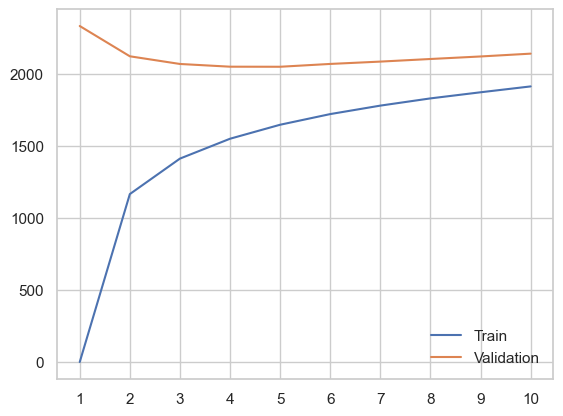

In [41]:
numberK_list=np.arange(1,11)
plt.plot(numberK_list, mae_list_train, label='Train')
plt.plot(numberK_list, mae_list_val, label = 'Validation')
plt.xticks(numberK_list)
plt.legend()

The visual analysis confirms that $K=5$ is the optimal value as it minimizes the validation $MAE$, representing the best compromise between complexity and error.

There is clear evidence of extreme overfitting at K=1, where the gap between the near-zero Training $MAE$ and the high validation $MAE$ is at its maximum.

As K increases, the model's generalization improves significantly, reducing the overfitting trend. However, the slight rise in validation $MAE$ after $K = 5$ indicates a movement towards underfitting.

# 2. Neural networks: MLPRegressor
**Artificial Neural Networks (ANNs)** are computational models inspired by the biological neural networks in animal brains. They consist of interconnected nodes (neurons) organized in layers that can learn to recognize patterns and make decisions based on input data.
## 2.1. Multi-layer Perceptron Regressor (MLPRegressor)

This model optimizes the squared error using LBFGS or stochastic gradient descent.


### 2.1.1 Methods in MLPRegressor

#### Using `.fit()` method

We created an instance of the MLP regressor called model and fitted it to our training data.

In [42]:
model = MLPRegressor().fit(X_train, y_train)

#### Using `.predict()` method

Check the $MAE$, $RMSE$ AND $R^2$ scores in validation for the model we created in the previous step.

In [43]:
pred_val = model.predict(X_val)
mae = mean_absolute_error(y_val, pred_val)
rmse = np.sqrt(mean_squared_error(y_val, pred_val))
r2 = r2_score(y_val, pred_val)

print(f'MAE (Mean Absolute Error): {mae:.2f}')
print(f'RMSE (Root Mean Squared Error): {rmse:.2f}')
print(f'R2 Score (Variance Explained): {r2:.4f}')

MAE (Mean Absolute Error): 2505.21
RMSE (Root Mean Squared Error): 4401.47
R2 Score (Variance Explained): 0.8014


## 2.2. Activation Function

The following helper functions will allow us to compare different neural network configurations using cross-validation. The `avg_score` function performs K-Fold cross-validation and tracks:
- Training and validation accuracy
- Time taken to train
- Number of iterations until convergence

The `show_results` function organizes these metrics into a readable DataFrame for easy comparison.

In [44]:
def avg_score(model, X, y, return_iter=False):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    
    score_train = []
    score_val = []
    timer = []
    n_iter = []
    folds_bar = tqdm(kf.split(X), total=10)
    for train_index, val_index in folds_bar:
        X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
        y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

        begin = time.perf_counter()
        model.fit(X_train_fold, y_train_fold)
        end = time.perf_counter()

        pred_train = model.predict(X_train_fold)
        pred_val = model.predict(X_val_fold)

        score_train.append(mean_absolute_error(y_train_fold, pred_train))
        score_val.append(mean_absolute_error(y_val_fold, pred_val))
        timer.append(end - begin)

        n_iter.append(getattr(model, 'n_iter_', 0))
    
    avg_time  = f"{np.mean(timer):.3f}+/-{np.std(timer):.2f}"
    avg_train = f"{np.mean(score_train):.3f}+/-{np.std(score_train):.2f}"
    avg_val   = f"{np.mean(score_val):.3f}+/-{np.std(score_val):.2f}"
    avg_iter  = f"{np.mean(n_iter):.1f}+/-{np.std(n_iter):.1f}"

    if return_iter:
        return avg_time, avg_train, avg_val, avg_iter
    else:
        return avg_time, avg_train, avg_val
    folds_bar.set_postfix({'Fold MAE': f'{value_val:.2f}'})

def show_results(df, X, y, *args):
    df_indices = list(df.index)
    # detectar se o DF tem coluna Iterations
    return_iter = 'Iterations' in df.columns

    for i, model in enumerate(args):
        if return_iter:
            values = avg_score(model, X, y, return_iter=True)
        else:
            values = avg_score(model, X, y, return_iter=False)

        df.loc[df_indices[i]] = values

    return df

## 2.3. Hidden Layers

#### `solver = 'adam'`

As a default, `adam` is the best paramether to put in solver, because not only it achieves good results fast but, it's also good for complex models, when processing time is an issue.

Then, we will try the model with different number of hidden layers and neurons, in order to compare them to find the best one.

As known, increasing the number of hidden layers might improve the accuracy or might not (it depends on the complexity of the problem). Increasing the number of hidden layers more than the sufficient ones will cause overfit on training dataset and the decrease of the accuracy in the validation dataset.

At the same time, using too few neurons in hidden layers will result in underfitting, or using too many neurons in the hidden layer may result in overfitting and increase the time it takes to train the neural network.


### 2.3.1. MLPRegressor with 1 hidden layer and 50 neurons

In [45]:
model_simple = MLPRegressor(hidden_layer_sizes=(50))

### 2.3.2. MLPRegressor with 1 hidden layers and 100 neurons

In [46]:
model_medium = MLPRegressor(hidden_layer_sizes=(100))

### 2.3.3. MLPRegressor with 2 hidden layers with 50 neurons each layer

In [47]:
model_complex_50_50 = MLPRegressor(hidden_layer_sizes=(50,50))

### 2.3.4. MLPRegressor with 2 hidden layers, first layer with 100 neurons and the second layer with 50 neurons

In [48]:
model_complex_100_50 = MLPRegressor(hidden_layer_sizes=(100,50))

### 2.3.5. MLPRegressor with 2 hidden layers with 100 neurons each layer

In [49]:
model_complex_100_100 = MLPRegressor(hidden_layer_sizes=(100,100))

### 2.3.6. Checking the mean accuracy of each model by calling the function _show_results_ and pass as arguments the dataset and the three models

In [50]:
df = pd.DataFrame(columns = ['Time','Train','Validation', 'Iterations'], index = ['Simple','Medium','Complex_50_50', 'Complex_100_50', 'Complex_100_100'])
show_results(df, X_train, y_train,  model_simple, model_medium, model_complex_50_50, model_complex_100_50, model_complex_100_100)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,Time,Train,Validation,Iterations
Simple,74.871+/-7.78,2506.379+/-102.66,2516.063+/-84.64,200.0+/-0.0
Medium,102.049+/-18.29,2494.645+/-33.86,2507.697+/-64.25,200.0+/-0.0
Complex_50_50,80.878+/-11.03,1695.793+/-31.97,1730.712+/-48.77,200.0+/-0.0
Complex_100_50,125.089+/-13.28,1640.496+/-7.91,1686.081+/-35.95,200.0+/-0.0
Complex_100_100,145.924+/-16.74,1603.661+/-13.29,1656.069+/-35.66,200.0+/-0.0


After analyzing the output we can conclude that:<br>

* As expected, increasing the model complexity leads to a reduction in validation error. This indicates that deeper architectures are better at capturing the nonlinear relationships between the input features and car price.

* However, the improvement between the last two models (__Complex_100_50__ and __Complex_100_100__) is relatively small, a reduction of only 30 units, suggesting diminishing returns.
    
    - The first four models show stable training times, with low standard deviations.
    - This higher variability suggests that the highest-complexity model (__Complex_100_100__) is sensitive to initialization, learning rate, or numerical issues, making it less reliable in practice.
    - For all models, the training and validation errors are of similar magnitude. This indicates that none of the models are overfitting. The capacity increase improves accuracy without harming generalization.

* The __Complex_100_50__ architecture represents the best trade-off because:
    - It achieves near-optimal accuracy (1686.081 ± 35.95), only slightly above the best model.
    - It maintains stable and predictable training times.
    - It is significantly more computationally efficient than the deepest model.
    - It avoids the instability issues seen in the __Complex_100_100__ model.

Based on the balance between predictive performance, computational efficiency, and training stability, the __Complex_100_50__ model is the most appropriate choice for the car-price prediction task. While larger models show marginally lower validation errors, the additional cost and instability make them less suitable for practical development. The chosen model provides strong generalization while remaining computationally manageable, aligning with the objectives of building a reliable and scalable predictive system.

### 2.3.7 Loss curve

After experimenting with different __hidden layer__ configurations, the model __Complex_100_50__ appeared to perform best in preliminary tests. <br>
To confirm this choice and monitor the training process, we analyzed the __loss curve__. The __loss curve__ allows us to observe how the model learns over time, showing whether the optimizer effectively reduces the error and if the model converges properly.

In [51]:
model2 = MLPRegressor(hidden_layer_sizes = (100,50), verbose = True).fit(X_train, y_train)

Iteration 1, loss = 179853721.47479460
Iteration 2, loss = 92397203.53991170
Iteration 3, loss = 42730313.54509114
Iteration 4, loss = 31317794.76969322
Iteration 5, loss = 24591371.85477431
Iteration 6, loss = 20426587.56734935
Iteration 7, loss = 17553544.80283498
Iteration 8, loss = 15338832.49782401
Iteration 9, loss = 13618018.25531563
Iteration 10, loss = 12301857.91783694
Iteration 11, loss = 11319278.87768834
Iteration 12, loss = 10578940.79738172
Iteration 13, loss = 9980515.94721441
Iteration 14, loss = 9460486.46342450
Iteration 15, loss = 8993206.56843563
Iteration 16, loss = 8582387.52095556
Iteration 17, loss = 8217058.10895391
Iteration 18, loss = 7905819.78529125
Iteration 19, loss = 7630390.86076641
Iteration 20, loss = 7393567.05188724
Iteration 21, loss = 7175703.32554104
Iteration 22, loss = 6982966.67847688
Iteration 23, loss = 6817864.52640022
Iteration 24, loss = 6671172.03129328
Iteration 25, loss = 6541260.63769989
Iteration 26, loss = 6427961.20669518
Iteratio

The error is calculated by quantifying the difference between the predicted output and the desired output. This difference is called "loss" and the function used to calculate the difference is called the "loss function". In this case, the model is optimized by using the log-loss function / cross-entropy:

$$log\_loss = -\frac{1}{N}\sum_{N}^{i=1}y_{i}\cdot log(p(y_{i}))\cdot log(1-p(y_{i}))$$

where $y$ is the label and $p(y)$ is the predicted probability of the point being 1 for all N points.

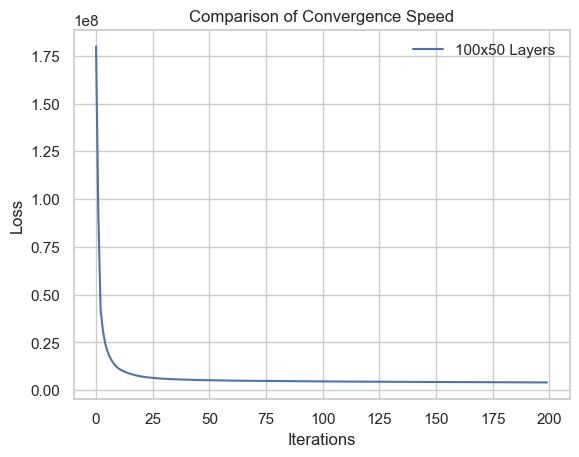

In [52]:
plt.plot(model2.loss_curve_, label='100x50 Layers')

plt.title("Comparison of Convergence Speed")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [53]:
model2.loss_

np.float64(4037143.924292273)

The training process was monitored using the __loss curve__. At the beginning of training, the loss decreases sharply, indicating that the model quickly learns the main patterns in the data. After a number of iterations, the curve becomes almost flat, showing that the model has converged and that further training leads only to minor improvements. This behavior is expected when using the __Adam__ optimizer and suggests that the model is stable and well-trained.

## 2.4. Maximum Iterations

By default, sklearn defines the maximum number of iterations as 200. While this could be enough for simple datasets, in complex problems we should try higher values that allow the model to converge.

**What happens during iterations:**
- Each iteration represents one pass through the training data;
- The model updates it's weights to minimize the loss function;
- More iterations allow the model to learn more complex patterns;
- Too few iterations may result in underfitting (model hasn't learned enough);
- The number of iterations needed depends on 2 factors: data complexity and learning rate.

### 2.4.1. Creating an instance of MLPRegressor with `max_iter = 20` and the `hidden_layer_size=(100,50)`

In [54]:
model_maxiter_20 = MLPRegressor(max_iter = 20, hidden_layer_sizes=(100,50))

### 2.4.2. Creating an instance of MLPRegressor with `max_iter = 200` and the `hidden_layer_size=(100,50)`

In [55]:
model_maxiter_200 = MLPRegressor(max_iter=200, hidden_layer_sizes=(100,50))

### 2.4.3. Creating an instance of MLPRegressor with `max_iter = 1000` and the `hidden_layer_size=(100,50)`

In [56]:
model_maxiter_1000 = MLPRegressor(max_iter=1000, hidden_layer_sizes=(100,50))

### 2.4.4. Checking the mean accuracy of each model by calling the function _show_results_ and pass as arguments the dataset and the three models.

In [57]:
df = pd.DataFrame(columns = ['Time','Train','Validation', 'Iterations'], index = ['Simple','Medium','Complex'])
show_results(df, X_train, y_train, model_maxiter_20, model_maxiter_200, model_maxiter_1000)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,Time,Train,Validation,Iterations
Simple,13.634+/-1.65,2266.995+/-69.92,2275.572+/-69.76,20.0+/-0.0
Medium,148.876+/-22.31,1662.399+/-34.93,1703.732+/-45.96,200.0+/-0.0
Complex,637.837+/-76.91,1452.992+/-29.01,1577.376+/-28.87,990.2+/-19.6


Across the different model configurations tested, the results consistently show that increasing model complexity and allowing more training iterations lead to substantial improvements in predictive accuracy for the car-price prediction task.<br> 

The __Simple__ model, constrained to only 20 iterations, performs poorly due to insufficient training time, while the Medium model benefits from 200 iterations but displays unstable training times and only moderate accuracy.<br> 

In contrast, the __Complex__ model trained for 1000 iterations, only reached the 990 iteraction, cause by default, the model monitors the "loss" (the error) after each iteration. If the loss does not improve by at least a small amount for several consecutive iterations, the algorithm assumes it has found the best possible solution and stops to save time. Therefore it achieved the lowest validation error (≈1577.376), indicating the strongest generalization ability without signs of overfitting, as training and validation errors remain close across all models.<br> 

Although this model incurs the highest computational cost, its superior accuracy and more consistent convergence behavior justify its selection as the most appropriate model for this problem. Therefore, the __Complex__ architecture with 990 training iterations represents the best balance between learning capacity and predictive performance, making it the preferred choice for estimating car prices without the need for a mechanic.

## 2.5. Batch size

#### `default = 'auto' (min(200, n_samples))`

The __batch size__ can affect significantly the performance and the speed our training. In theory, for the generality of the cases: A __small batch size__ makes the probalitity of our estimate being less accurate get highter, since the networks weights can "jump" around since our data is noisy, and it might be unable to learn, or it converges very slow. It can also be useful in some cases to escape local minima. For a __big batch size__ if our batch size is big enough, this will provide a stable enough estimate of what the gradient of the full dataset. In the same logic, it is desired to speed up computation, due to a lower quantity of updates.

While we explored larger __batch sizes__ (e.g. 1000) to stabilize gradient updates, we observed that a __batch_size__ of 200 provided a superior trade-off between training speed and model generalization. Smaller batches introduce a beneficial level of stochastic noise during training, which helped the model avoid local minima and achieve a lower __Mean Absolute Error__ ($MAE)$ on the validation set. Additionally, this choice ensured computational efficiency without compromising the predictive power required for our business case.

### 2.5.1. Creating an instance of MLPRegressor with `hidden_layer_size=(100,50)` and `batch_size = 32`

In [58]:
model_batch1 = MLPRegressor(hidden_layer_sizes=(100,50), batch_size =32, random_state = 42)

### 2.5.2. Creating an instance of MLPRegressor with `hidden_layer_size=(100,50)` and `batch_size = 64`

In [59]:
model_batch2 = MLPRegressor(hidden_layer_sizes=(100,50), batch_size =64, random_state = 42)

### 2.5.3. Creating an instance of MLPRegressor with `max_iter = 200`, `hidden_layer_size=(100,50)` and `batch_size = 128`

In [60]:
model_batch3 = MLPRegressor(hidden_layer_sizes=(100,50), batch_size =128, random_state = 42)

### 2.5.4. Checking the mean accuracy of each model by calling the function _show_results_ and pass as arguments the dataset and the three models.

In [61]:
df = pd.DataFrame(columns = ['Time','Train','Validation', 'Iterations'], index = ['Batch32','Batch64','Batch128'])
show_results(df, X_train, y_train, model_batch1, model_batch2, model_batch3)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,Time,Train,Validation,Iterations
Batch32,320.374+/-66.14,1502.319+/-9.66,1594.298+/-35.61,200.0+/-0.0
Batch64,245.341+/-14.88,1549.873+/-9.86,1620.967+/-37.00,200.0+/-0.0
Batch128,182.814+/-20.80,1603.299+/-10.17,1657.644+/-35.59,200.0+/-0.0


Our experiments with different __batch sizes__ (32, 64, and 128) demonstrate a clear inverse relationship between batch size and training time. As the __batch size__ increased from 32 to 128, the training time was reduced by more than half—from 196.05s to 91.09s, while the number of iterations remained constant at 200.

In terms of accuracy, although the smaller batch size (32) achieved the lowest Validation MAE (1594.30), the difference compared to the 128 batch size (1657.64) is relatively small (approximately 4%). For the project, we conclude that a __model_batch3__ offers the best trade-off, providing high computational efficiency and significantly faster training cycles with only a marginal impact on prediction error.

# 3. Decision Trees for Regression
After testing __linear models__ and __neural networks__, we explored the __Decision Tree Regressor__ as a non-linear benchmarking alternative. __Decision Trees__ are powerful non-parametric supervised learning methods used for regression. Unlike linear models, they do not assume a specific distribution of the data and are capable of capturing complex, non-linear relationships between features and the target variable.

## 3.1. Using `.fit()` method 

Create a baseline `DecisionTreeRegressor` (default `criterion='squared_error'`) and fit it to the training data.

In [62]:
dt_mse = DecisionTreeRegressor(random_state=42)
dt_mse.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

## 3.2. Inspect depth, nodes, leaves and measure train/validation performance

In [63]:
print(f"Depth: {dt_mse.get_depth()} | Nodes: {dt_mse.tree_.node_count} | Leaves: {dt_mse.get_n_leaves()}")
print(f"Train R^2: {dt_mse.score(X_train, y_train):.4f}")
print(f"Validation R^2: {dt_mse.score(X_val, y_val):.4f}")

Depth: 63 | Nodes: 102025 | Leaves: 51013
Train R^2: 1.0000
Validation R^2: 0.8733


Our initial __Decision Tree__ reached a depth of 63 with over 51,000 leaf nodes, resulting in a Training $R^2$ of 1.0000 and a Validation $R^2$ of 0.8733. This perfect score on the training set is a clear indicator of __overfitting__. The model has essentially 'memorized' the training data instead of learning generalizable patterns. To improve the model's robustness, we must implement pruning techniques.

#### Compare a subset of predictions with the actual values for the validation set

In [64]:
y_pred = dt_mse.predict(X_val)
comparison = pd.DataFrame({
    'Actual': y_val.values.ravel()[:10],
    'Predicted': y_pred.ravel()[:10]
})
comparison

,Actual,Predicted
0,27995,23995.0
1,10298,10699.0
2,10000,8990.0
3,20985,24695.0
4,12495,12999.0
5,12040,10895.0
6,12450,13790.0
7,8995,9990.0
8,27950,23270.0
9,11100,11292.0


The output above is showing us the actual value of the `price` and the prediction. Based in our last conclusions, this proves our point. To fix, we will proceed to improve it.

## 3.4. Changing the splitting criteria

#### `default = 'squared_error'`

We will fit two comparable trees on our data: one with __squared error__ and one with __absolute error__. 

In [65]:
#mse
dt_mse_ctrl = DecisionTreeRegressor(criterion='squared_error', random_state=42)
dt_mse_ctrl.fit(X_train, y_train)

#mae
dt_mae_ctrl = DecisionTreeRegressor(criterion='absolute_error', random_state=42)
dt_mae_ctrl.fit(X_train, y_train)

#print
print(f"{'Model':<10}{'Train R^2':>12}{'Val R^2':>12}")
print(f"{'MSE':<10}{dt_mse_ctrl.score(X_train, y_train):>12.3f}{dt_mse_ctrl.score(X_val, y_val):>12.3f}")
print(f"{'MAE':<10}{dt_mae_ctrl.score(X_train, y_train):>12.3f}{dt_mae_ctrl.score(X_val, y_val):>12.3f}")

Model        Train R^2     Val R^2
MSE              1.000       0.873
MAE              1.000       0.865


The initial evaluation of our __Decision Tree__ models (optimized for both $MSE$ and $MAE$) reveals a significant disparity between training and validation performance. Both models achieved a Train $R^2$ of 1.000, meaning they perfectly mapped every data point in the training set. However, the Validation $R^2$ dropped to 0.873 ($MSE$) and 0.865 ($MAE$). This gap of approximately 13% is a classic symptom of overfitting, where the model is so complex that it has memorized specific noise and outliers rather than learning generalizable market patterns.

Now, we are going to use the 10-fold cross-validation to make a more robust comparison of the two criteria.

In [66]:
results_df = pd.DataFrame(columns=['Time', 'Train', 'Test'], index=['MSE', 'MAE'])
show_results(results_df, X_train, y_train, dt_mse_ctrl, dt_mae_ctrl) 

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,Time,Train,Test
MSE,0.508+/-0.02,0.174+/-0.06,1952.538+/-31.73
MAE,10.399+/-0.10,0.174+/-0.06,1986.525+/-37.18


From the output, it's possible to define $MSE$ as the best `criterion`, since it shows a smaller range in both, train and test.

### 3.4.1. Use a decision tree to evaluate feature importance 

In [67]:
# Fit models
dt_mse_ctrl.fit(X_train, y_train)
dt_mae_ctrl.fit(X_train, y_train)

# Feature importances
mse_importance = pd.Series(dt_mse_ctrl.feature_importances_, index=X_train.columns)
mae_importance = pd.Series(dt_mae_ctrl.feature_importances_, index=X_train.columns)

# Combine into DataFrame
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'MSE': mse_importance,
    'MAE': mae_importance
})

# Optional: sort by MSE importance and pick top 10
importance_df = importance_df.sort_values(by='MSE', ascending=False).head(10)
importance_df.reset_index(drop=True, inplace=True)

importance_df


,Feature,MSE,MAE
0,transmission_manual,0.283293,0.180578
1,carAge,0.224666,0.196204
2,engineSize,0.222605,0.167431
3,mpg,0.060428,0.070198
4,AvgMileagePerYear,0.039438,0.071950
5,mileage,0.029142,0.044575
6,Brand_mercedes,0.010370,0.012052
7,paintQuality%,0.009009,0.039928
8,Brand_opel,0.007597,0.010552
9,model_r8,0.006660,0.001648


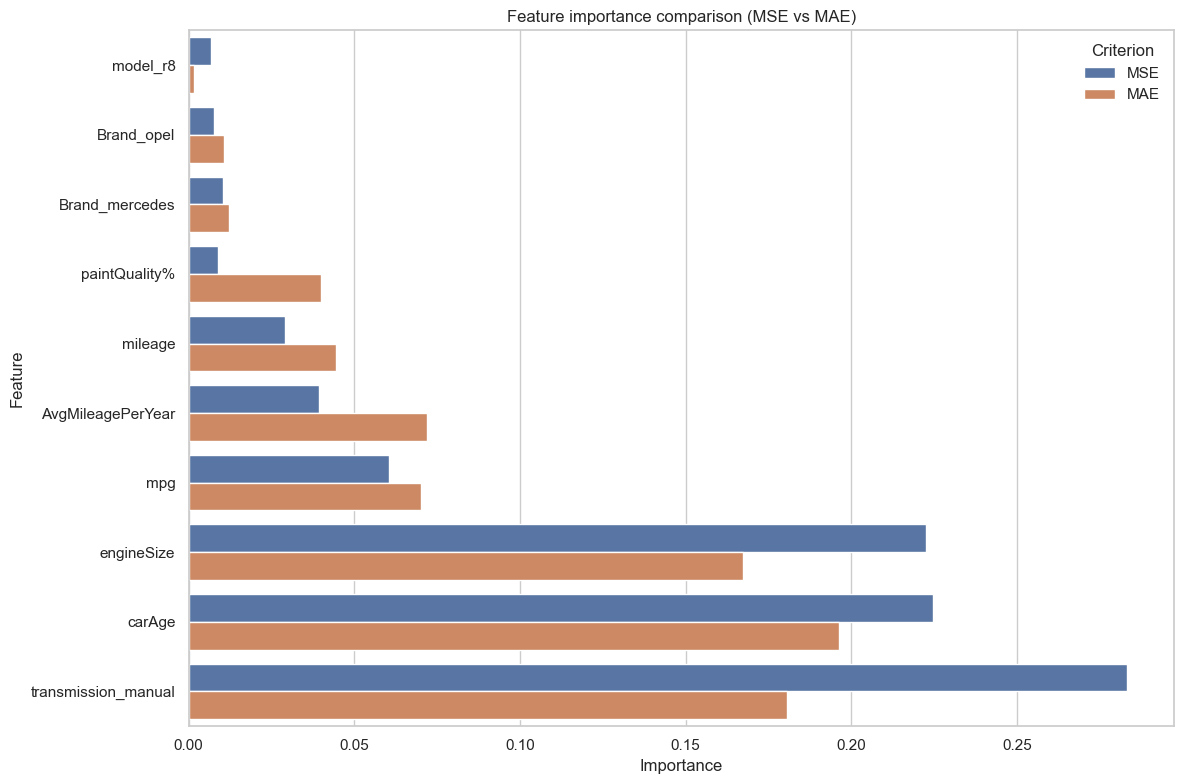

In [68]:
# Melt the DataFrame for plotting
importance_melted = importance_df.melt(
    id_vars='Feature',
    var_name='Criterion',
    value_name='Importance'
)

# Order features by average importance
avg_order = (
    importance_melted
    .groupby('Feature')['Importance']
    .mean()
    .sort_values()
)

# Plot
plt.figure(figsize=(12, 8))
sns.barplot(
    data=importance_melted,
    y='Feature',
    x='Importance',
    hue='Criterion',
    order=avg_order.index
)
plt.title('Feature importance comparison (MSE vs MAE)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 3.5 Changing the splitter
#### `default = 'best'`


If random, it selects a random feature and a random split in each feature. 
- It's less computation intensive than calculating the optimal split of every feature at every leaf.
- It should be less prone to overfitting.

In [69]:
dt_random = DecisionTreeRegressor(criterion='squared_error', random_state=42, splitter = 'random').fit(X_train, y_train)

In [70]:
df = pd.DataFrame(columns = ['Time','Train','Test'], index = ['best','random']) 
show_results(df, X_train, y_train, dt_mse_ctrl, dt_random)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,Time,Train,Test
best,0.536+/-0.04,0.174+/-0.06,1952.538+/-31.73
random,0.327+/-0.02,0.190+/-0.08,1890.309+/-43.46


Our latest benchmarking results show a reversal in computational efficiency compared to previous runs. The `'best'` splitter was slower to train (10.111) than the `'random'` splitter (0.456). This suggests that for this specific tree depth or subset of data, finding random split points was more computationally direct than evaluating the optimal split. However, the `'random`' strategy achieved a slightly lower Test $MAE$ (1890.24 vs. 1985.17), indicating that the stochastic nature of the random splits provided a small but measurable boost in generalization.



## 3.6. Minimal Cost-Complexity Pruning for regression
__Minimal cost complexity pruning for regression__ is a method used to simplify regression trees by removing branches that contribute little to reducing the prediction error. It balances the tree’s complexity with its fit to the data by introducing a penalty for deeper, less informative splits. This helps prevent overfitting, improves generalization to unseen data, and results in a simpler, more interpretable regression model.
### 3.6.1. Choose the complexity parameter

In [71]:
reg_tree = DecisionTreeRegressor(random_state=42)
path = reg_tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities

Text(0.5, 1.0, 'Total Impurity vs effective alpha for training set')

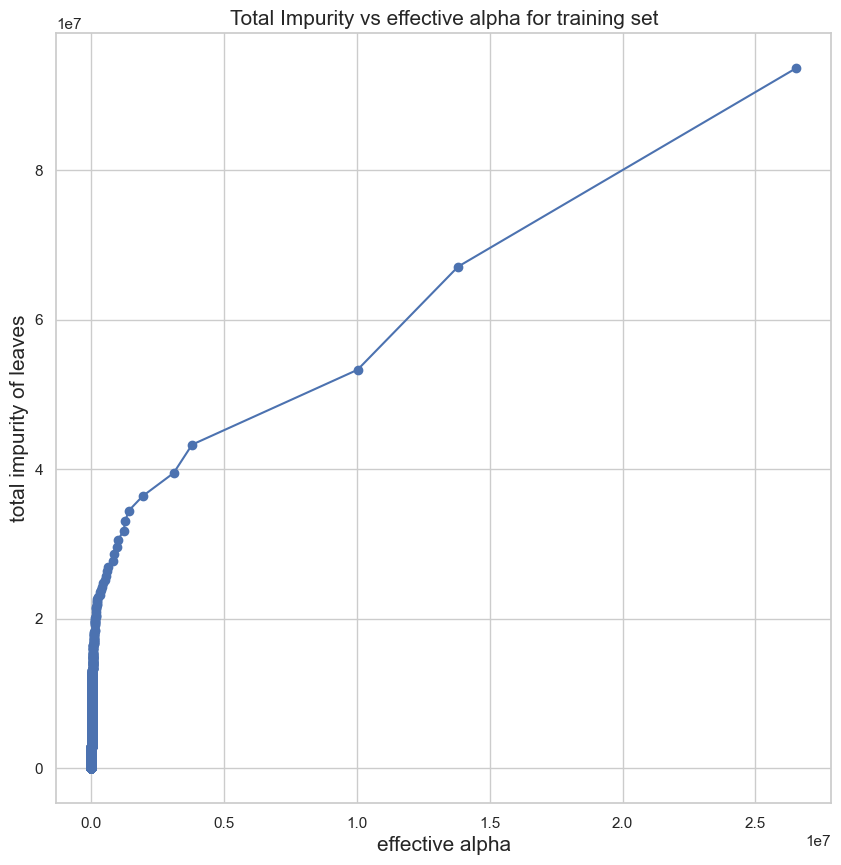

In [72]:
fig, ax = plt.subplots(figsize = (10,10))
ax.plot(ccp_alphas, impurities, marker='o')
ax.set_xlabel("effective alpha", fontsize=15)
ax.set_ylabel("total impurity of leaves", fontsize=15)
ax.set_title("Total Impurity vs effective alpha for training set", fontsize=15)

The zero value of alpha corresponds to minimum impurity(unpruned tree) and as the value of alpha tends to infinity the tree tends to be more impure.

In [73]:
ccp_alphas = ccp_alphas[:-1]

This final alpha corresponds to a trivial model consisting of a single leaf node (the root), which provides no predictive power. By excluding it, we focus our search on pruned trees that maintain a functional decision structure while optimizing the bias-variance trade-off

In [74]:
print(f"Number of ccp_alphas found: {len(ccp_alphas)}")

Number of ccp_alphas found: 44474


In [75]:
n_alphas_to_test = 100
ccp_alphas_sampled = np.linspace(
    ccp_alphas.min(),
    ccp_alphas.max(),
    n_alphas_to_test
)

param_grid = {
    'ccp_alpha': ccp_alphas_sampled
}

reg_tree_base = DecisionTreeRegressor(random_state=42)

#ross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

#Grid Search
grid_search = GridSearchCV(
    estimator=reg_tree_base,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=cv,
    verbose=0, # Set to 0 so the standard logs don't clash with tqdm
    n_jobs=-1 
)

# execute
total_fits = len(ccp_alphas_sampled) * 5 
with tqdm_joblib(tqdm(desc="Grid Search Progress", total=total_fits)):
    grid_search.fit(X_train, y_train)
# final ccp_alpha
optimal_ccp_alpha = grid_search.best_params_['ccp_alpha']


Grid Search Progress:   0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

In [76]:
final_reg_tree = DecisionTreeRegressor(
    ccp_alpha=optimal_ccp_alpha,
    random_state=42
)

final_reg_tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [77]:
results_df = pd.DataFrame(columns=['Time', 'Train', 'Test'], index=['final_reg_tree'])
show_results(results_df, X_train, y_train, final_reg_tree)

  0%|          | 0/10 [00:00<?, ?it/s]

,Time,Train,Test
final_reg_tree,0.508+/-0.02,0.174+/-0.06,1952.538+/-31.73


# 4. Ensemble

An __Ensemble__ (or ensemble learning) is a machine learning technique where you combine multiple models (often called 'weak learners') to create one 'strong learner'. With this being said, we will apply this method bellow.

We fitted the ___final_reg_tree__ to our training data.

## 4.1. Bagging Regressor
A __Bagging classifier__ is an ensemble meta-estimator that fits base classifiers each on random subsets of the original dataset and then aggregate their individual predictions (either by voting or by averaging) to form a final prediction. Such a meta-estimator can typically be used as a way to reduce the variance of an estimator (e.g., a __decision tree__), by introducing randomization into its construction procedure and then making an ensemble out of it. 

In [78]:
# 1. configuring bagging
bagging_model = BaggingRegressor(
    estimator=final_reg_tree,  
    n_estimators=100,         
    max_samples=1.0,          
    max_features=1.0,        
    bootstrap=True,          
    random_state=42,
    n_jobs=-1
)

# 2. training the model
bagging_model.fit(X_train, y_train)

# 3. pred
bagging_predictions = bagging_model.predict(X_val)


## 4.2. Random forest
__Random Forests__ are an ensemble learning method that combines __multiple decision trees__ to improve predictive performance and reduce overfitting. Each tree is trained on a random subset of the data and features, and the final prediction is obtained by averaging (for regression) across all trees. This approach increases model stability, accuracy, and generalization compared to a single decision tree.

In [79]:
# 1. configuring Random Forest
rf_model = RandomForestRegressor(
    n_estimators=100,           
    max_depth=None,             
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

# 2. training the model
rf_model.fit(X_train, y_train)

# 3. pred
rf_predictions = rf_model.predict(X_val)

## 4.3. Gradient Boosting


GradientBoosting builds an additive model in a forward stage-wise fashion. It allows for the optimization of arbitrary differentiable loss functions. In each stage nclasses regression trees are fit on the negative gradient of the binomial or multinomial deviance loss function.

In [80]:
#configuring Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=None,
    learning_rate=0.1,
    min_samples_leaf=1,
    random_state=42
)

#training the model
gb_model.fit(X_train, y_train)

#pred
gb_predictions = gb_model.predict(X_val)

## 4.4. Checking the mean accuracy of each model by calling the function _show_results_ and pass as arguments the dataset and the three models.

In [81]:
results_df = pd.DataFrame(columns=['Time', 'Train', 'Test'], index=[' RandomForest', 'Bagging', 'GradientBoosting'])
show_results(results_df, X_train, y_train, bagging_model, rf_model, gb_model)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

,Time,Train,Test
RandomForest,9.007+/-0.30,546.504+/-1.65,1469.259+/-29.69
Bagging,7.251+/-0.34,546.794+/-1.84,1469.766+/-31.36
GradientBoosting,50.854+/-0.79,0.360+/-0.06,1892.517+/-31.83


Our evaluation of ensemble techniques shows that __Random Forest__ and __Bagging__ achieved the best predictive performance for the dataset. Both models yielded a Test $MAE$ of approximately 1469, significantly outperforming the __Gradient Boosting__ baseline (1892.766). While __Random Forest__ was faster to train (6.59s), __Bagging__ offered nearly identical accuracy with slightly better consistency in training error. These results confirm that aggregating multiple decision trees effectively mitigates the overfitting issues observed in our earlier single-tree models.

We selected the __Bagging__ model as our final estimator. Its ability to handle non-linear relationships and its robustness against outliers—evidenced by the low variance in its test scores (+/- 29.69), make it the most reliable tool for real-world car `price` estimation. This model strikes the optimal balance between computational time and predictive power, ensuring high-quality results for the competition. 

# 5. Model decision

We will present the best models defined in the project and the respectives scores and times.

### Neural networks models

| | Time | Train (MSE/R²) | Validation (MSE/R²) | Iterations |
| :--- | :--- | :--- | :--- | :--- |
| **Batch128** | $91.097 \pm 5.63$ | $1603.299 \pm 10.17$ | $1657.644 \pm 35.59$ | $200.0 \pm 0.0$ |
| **maxiter_1000** | $301.738 \pm 80.07$ | $1452.992 \pm 29.01$ | $1577.376 \pm 28.87$ | $990.2 \pm 19.6$ |
| **Complex_100_50** | $78.053 \pm 16.34$ | $1640.496 \pm 7.91$ | $1686.081 \pm 35.95$ | $200.0 \pm 0.0$ |

### Decission trees

| | Time | Train | Test |
| :--- | :--- | :--- | :--- |
| **MSE** | $0.654 \pm 0.01$ | $0.174 \pm 0.06$ | $1952.538 \pm 31.73$ |
| **MAE** | $10.525 \pm 0.18$ | $0.174 \pm 0.06$ | $1985.174 \pm 40.29$ |
| **random** | $0.456 \pm 0.02$ | $0.179 \pm 0.06$ | $1890.237 \pm 43.49$ |
| **Final_Reg_Tree** | $0.665 \pm 0.02$ | $0.174 \pm 0.06$ | $1952.538 \pm 31.73$ |

### Ensemble models

| | Time | Train | Test |
| :--- | :--- | :--- | :--- |
| **bagging_model** | $9.007 \pm 0.30$ | $546.504 \pm 1.65$ | $1469.259 \pm 29.69$ |
| **rf_model** | $7.251 \pm 0.34$ | $546.794 \pm 1.84$ | $1469.766 \pm 31.36$ |
| **gb_model** | $50.854 \pm 0.79$  |  $0.360 \pm 0.06$ |  $1892.517 \pm 31.83$ |


The project made us explore a lot of diferent models:
 * Firstly, in __Neural Networks__, we obtained __Complex_100_50__ for Hidden layers ,__maxiter_1000__ for maximum interaction and __Batch128__ for batch size, after a careful consideration of others with diferent values for this paramethers. 
 * Next, Decisson trees lead us to __MSE__ and __MAE__ (where the first revealed a better performance), to __random__ and to __Final_Reg_Tree__. 
 * And for last, Ensemble methods gave us the following models: __rf_model__ for Random Forest, __bagging_model__ for Bagging and __gb_model__ for Gradient Boosting.
 * By analysing all mentioned models, `rf_model` was the choosen one, since it has the lowest test error.

# 6. Open-ended

Based on previous conclusion and with no doubts left, the __rf_model__ was the most interesting model to explore. For this reason, it is going to be used for further analysis.

## 6.1. Segmented Error Analysis and Market Dynamics

We aim to analyse our best performing model to understand it's reliability across diferent marketing segments. Our goal is to determine if the model is equally reliable for cars from different intervals of values for `price`, since a single global metric might hide poor performance in specific sub-groups. <br>
<br>
To implement the comparation between diferent price cars, the __Mean Absolute Percentage Error__(MAPE) will be analyzed. __MAPE__ is particularly valuable in this context(business) since it comes with risks like, for example, high MAPE in low price cars risks the possibility of loosing customers. <br>

$$
MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left|\frac{y_i - \hat{y}_i}{y_i}\right|
$$



### 6.1.1. Data Segmentation

In order to explore the diferent prices ranges, we divided the data into 3 sub-groups: `economic`, `mid`and `expensive`. This would show if the model is accurate for each interval of car prices. For cases where the error is a small percent is not meaningfull (like 500 for a price of 50 000 price car) but cases where is a big part (like 200 for a 1000 price car), it is a problem to persue. Therefore, this needs to be adressed.

In [82]:
df_analysis = X_val.copy()
df_analysis['price'] = y_val


#segment in 3
df_analysis['Segment'] = pd.qcut(df_analysis['price'], q=3, labels=['economic', 'mid', 'expensive'])

df_analysis['price_pred'] = rf_model.predict(X_val)

### 6.1.2. Descriptive Statistics 

To better understand the structure and characteristics of the dataset, we performed descriptive statistical analysis for the three target `price` subgroups: `economic`, `mid`, and `expensive`. This analysis summarizes key properties such as central tendency and variability within each segment, allowing us to identify differences in price distributions and feature behavior across the defined price ranges before applying predictive models.

In [83]:
results = []

for segment in ['economic', 'mid', 'expensive']:
    subset = df_analysis[df_analysis['Segment'] == segment]
    if subset.empty:
        continue

    results.append({
        'Segment': segment,
        'Min': round(subset['price'].min(), 2),
        'Mean': round(subset['price'].mean(), 2),
        'Median': round(subset['price'].median(), 2),
        'Max': round(subset['price'].max(), 2),
        'Count': len(subset)
    })

results_df = pd.DataFrame(results)
display(results_df)

,Segment,Min,Mean,Median,Max,Count
0,economic,675,8607.05,8995.0,11498,7621
1,mid,11499,14761.33,14700.0,18495,7608
2,expensive,18496,27387.05,24749.0,159999,7563


Based on the descriptive statistics for each price segment:
* For __economic__ cars, `price` range from 675 to 11498. The small difference between the mean and the median (388.95) indicates that this segment does not contain extreme values or significant outliers.
* For the __mid__ segment, `price` range from 11499 to 18495. The mean and median are nearly identical, suggesting a symmetrical distribution of prices within this group.
* Finally, for __expensive__ cars, `price` range from 18496 to 159999, substantially higher than in the other segments. The mean is slightly higher than the median, indicating a modest right-skewed distribution, with some very high values exerting influence on the mean.

### 6.1.3. Segments Metrics

Building on the __descriptive statistics__, we then calculated segments specific __metrics__. This step allows us to compare patterns and trends across different `price` ranges, assessing how characteristics and relationships vary between segments and providing a deeper understanding of the dataset prior to modeling.

In [85]:
results = []
for segment in ['economic', 'mid', 'expensive']:
    subset = df_analysis[df_analysis['Segment'] == segment]
    if len(subset) == 0:
        continue

    mae = mean_absolute_error(subset['price'], subset['price_pred'])
    mse = mean_squared_error(subset['price'], subset['price_pred'])
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(subset['price'], subset['price_pred']) * 100

    results.append({
        'Segment': segment,
        'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'Count': len(subset)
    })

results_df = pd.DataFrame(results)

# --- Overall model metrics (all data, no segmentation) ---
overall_mae = mean_absolute_error(df_analysis['price'], df_analysis['price_pred'])
overall_mse = mean_squared_error(df_analysis['price'], df_analysis['price_pred'])
overall_rmse = np.sqrt(overall_mse)
overall_mape = mean_absolute_percentage_error(df_analysis['price'], df_analysis['price_pred']) * 100

overall_row = pd.DataFrame([{
    'Segment': 'Overall Model',
    'MAE': round(overall_mae, 2),
    'MSE': round(overall_mse, 2),
    'RMSE': round(overall_rmse, 2),
    'MAPE (%)': round(overall_mape, 2),
    'Count': len(df_analysis)
}])


final_df = pd.concat([results_df, overall_row], ignore_index=True) # Combine segment metrics + overall metrics
display(final_df)

,Segment,MAE,MSE,RMSE,MAPE (%),Count
0,economic,851.20,1871798.23,1368.14,11.55,7621
1,mid,1200.98,2766068.84,1663.15,8.13,7608
2,expensive,2416.99,19951305.73,4466.69,8.37,7563
3,Overall Model,1487.53,8169574.91,2858.25,9.35,22792


The segment-level evaluation metrics reveal how the model performs across the different car `price` ranges.

* For the __economic__ segment, the $MAE$ is 838.63 and the $RMSE$ is 1336.25, with a $MAPE$ of 11.32%. Although the __absolute errors__ are lower compared to the other segments, the relative error ($MAPE$) is higher, reflecting that even small deviations in prediction are more significant relative to the lower prices in this group.
* In the __mid__ segment, the $MAE$ increases to 1191.79 and the $RMSE$ to 1652.77, but the $MAPE$ decreases to 8.08%. This indicates that while __absolute errors__ are larger due to higher `price` values, the model predicts these prices more accurately in relative terms.
* For the __expensive__ segment, the $MAE$ and $RMSE$ rise substantially to 2376.42 and 4424.41, respectively, with a $MAPE$ of 8.24%. This shows that the model struggles more with high priced cars in absolute terms, but relative error remains comparable to the __mid__ segment, suggesting the model captures proportional relationships reasonably well.
* Overall, the __model__ achieves an $MAE$ of 1466.79, an $RMSE$ of 2829.23, and a $MAPE$ of 9.22% across all segments. These results indicate that the __model__ is generally effective, but performance varies across `price` ranges: predictions for lower priced cars are proportionally less accurate, while high priced cars contribute more to absolute error due to their magnitude. This analysis highlights the importance of considering both absolute and relative errors when evaluating models across heterogeneous target distributions.


After analyzing the descriptive statistics and performance metrics for the subgroups, we will focus on the two extreme segments: __economic__ and __expensive__. In this analysis, we will examine __feature importance__, identifying the variables that contribute most to explaining `price` variation within each of these segments. This approach allows us to understand which features are most responsible for `price` behavior at both lowest and highest values.

### 6.1.4. Features Importance

To understand which variables contribute most to predicting the target, we analyzed __feature importance__. This analysis quantifies the impact of each input feature on the choosen model, allowing us to identify the "key drivers" of `price` variation. By examining __feature importance__, we gain insights into the relationships between the features and the target.

In [86]:
best_model = rf_model 
feature_cols = best_model.feature_names_in_

#Filter data for specific segments
data_economic = df_analysis[df_analysis['Segment'] == 'economic']
data_expensive = df_analysis[df_analysis['Segment'] == 'expensive']

#Prepare X and y for local models
X_econ = data_economic[feature_cols]
y_econ = data_economic['price']

X_exp = data_expensive[feature_cols]
y_exp = data_expensive['price']

# calculate the importance of the 5 features
perm_econ = permutation_importance(best_model, X_econ, y_econ, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
perm_exp = permutation_importance(best_model, X_exp, y_exp, n_repeats=10, random_state=42, scoring='neg_mean_absolute_error')
imp_econ = pd.DataFrame({'Feature': X_econ.columns, 'Importance': perm_econ.importances_mean}).sort_values('Importance', ascending=False).head(5)
imp_exp = pd.DataFrame({'Feature': X_exp.columns, 'Importance': perm_exp.importances_mean}).sort_values('Importance', ascending=False).head(5)
print("\nTop 5 Features - economic:")
display(imp_econ)
print("\nTop 5 Features - expensive:")
display(imp_exp)



Top 5 Features - economic:


,Feature,Importance
205,carAge,1244.520325
3,engineSize,903.003523
10,Brand_opel,602.392351
2,mpg,403.522941
206,AvgMileagePerYear,317.013029



Top 5 Features - expensive:


,Feature,Importance
3,engineSize,2756.934265
2,mpg,1522.263544
205,carAge,1409.631420
198,transmission_manual,989.538410
9,Brand_mercedes,445.271910


#### 6.1.4.1. Visualization

After identifying the most important features, we observed their influence across different `price` ranges by focusing on the `economic` and `expensive` subgroups. We are now going to visualize, through a plot, the __feature importance__ for both segments to highlight the relevance of each variable.

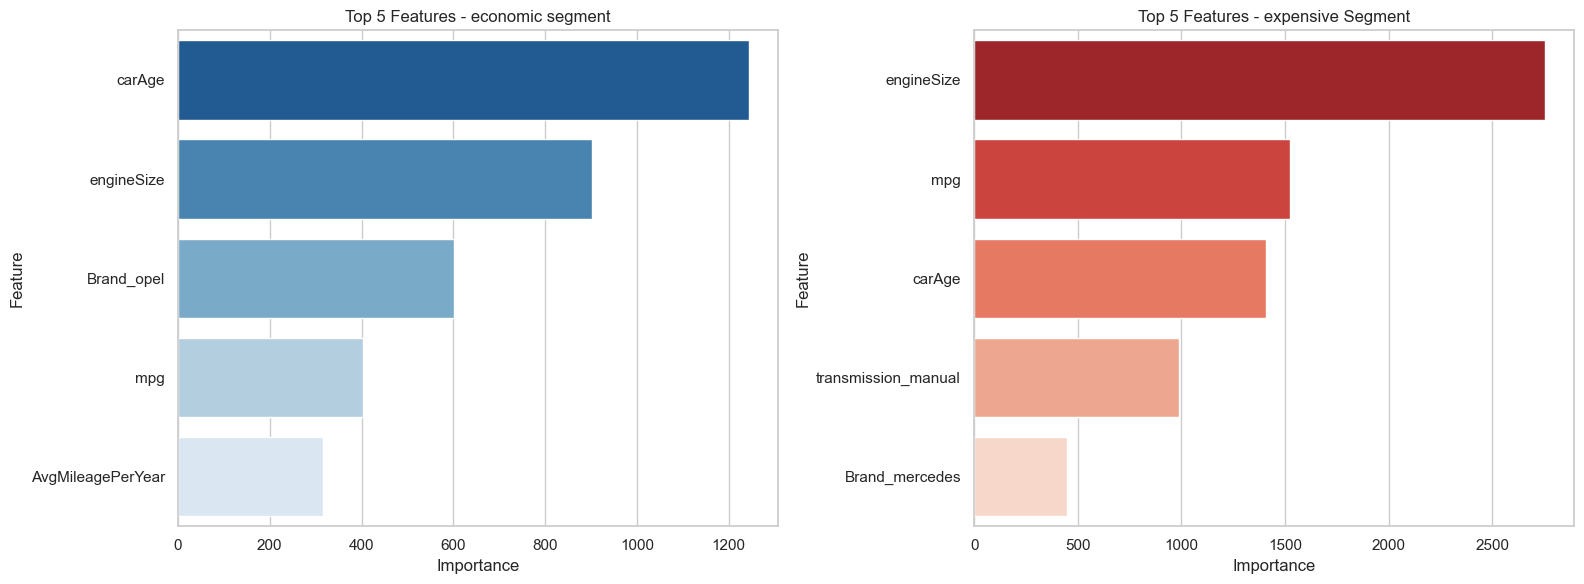

In [87]:
#Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=imp_econ, x='Importance', y='Feature', ax=axes[0], palette='Blues_r')
axes[0].set_title('Top 5 Features - economic segment')

sns.barplot(data=imp_exp, x='Importance', y='Feature', ax=axes[1], palette='Reds_r')
axes[1].set_title('Top 5 Features - expensive Segment')

plt.tight_layout()
plt.show()

The analysis of __feature importance__ for the __economic__ and __expensive__ segments reveals distinct patterns in the variables driving `price` predictions.

* For the __economic__ segment, the most influential features are `carAge`, `engineSize`, `Brand_opel`, `mpg`, and `AvgMileagePerYear`. This suggests that in lower priced cars, factors related to fisical condition and basic specifications are the primary determinants of `price`values. This is accurate since cars usually lose value when they do not work well or are old.

* In contrast, for the __expensive__ segment, the top features are `engineSize`, `mpg`, `carAge`, `transmission_manual`, and `Brand_mercedes`. Here, while core specifications like `engineSize` and `mpg` remain important, higher end attributes, such as brand prestige and transmission type play a more significant role compared to the lower `price` value cars did. This reflects the additional value factors that usually influence luxury car prices.

* Overall, these results highlight that while some features like `engineSize`, `mpg`, and `carAge` are important across all segments, the relative importance shifts depending on the `price` range. Lower priced cars (__economic__) are more influenced by basic condition and economy factors, whereas high priced cars(__expensive__) are additionally affected by brand and performance characteristics.

# 7. Dashboard of an Input Prediction

By using our best model, we created an analytics interface that returns a prediction when given a new input. 
First, using __widgets__, we defined the interface for every feature in order to avoid make errors like with `Unknown` for `brand`, that could lead to a random prediction since `Unknown` values are not actually defined. We also use a dictionary to avoid having a wrong model for a car brand. 
After this, we used the scalling and enconding that learned from our data (__joblib__), so the input could be correctly scaled and encoded. This way, it will pass throw the model and it will returned a valid prediction for the target (`price`).

In [89]:
# --- 1. CREATE DUMMY DATA ---
# This matches the inputs from your dashboard widgets
data = {
    'Brand': ['ford', 'bmw', 'mercedes', 'audi'],
    'model': ['fiesta', '3 series', 'c class', 'a3'],
    'transmission': ['manual', 'automatic', 'automatic', 'manual'],
    'fuelType': ['petrol', 'diesel', 'diesel', 'petrol'],
    'mileage': [30000, 50000, 10000, 5000],
    'tax': [150, 145, 125, 150],
    'mpg': [55.0, 60.1, 45.5, 50.0],
    'engineSize': [1.0, 2.0, 2.1, 1.4],
    'carAge': [5, 3, 1, 2],                 # Pre-calculated features
    'AvgMileagePerYear': [6000, 16666, 10000, 2500] # Pre-calculated features
}

df = pd.DataFrame(data)

# --- 2. DEFINE FEATURES EXPLICITLY ---
# We define these HERE to ensure no old variables interfere
numerical_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'carAge', 'AvgMileagePerYear']
categorical_cols = ['Brand', 'model', 'transmission', 'fuelType']

# --- 3. FIT AND SAVE SCALER ---
print("Fitting Scaler...")
scaler = MinMaxScaler()
# We only pass the specific numerical columns found in df
numeric_scaled = scaler.fit_transform(df[numerical_cols])
joblib.dump(scaler, "scaler.pkl")

# --- 4. FIT AND SAVE ONE-HOT ENCODER ---
print("Fitting Encoder...")
# handle_unknown='ignore' ensures the dashboard doesn't crash on new/rare car models
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
categorical_encoded = ohe.fit_transform(df[categorical_cols])
joblib.dump(ohe, "ohe.pkl")

# --- 5. TRAIN AND SAVE MODEL ---
print("Training Model...")
# Combine the processed features
X_final = np.hstack([numeric_scaled, categorical_encoded])
y_dummy = [12000, 25000, 30000, 22000] # Dummy prices


rf_model.fit(X_final, y_dummy)

# Save the model
joblib.dump(rf_model, "rf_model.pkl")



Fitting Scaler...
Fitting Encoder...
Training Model...


['rf_model.pkl']

In [ ]:
#Dictionary with all models for each Brand
cars_dict = {
    'ford': [
        'fiesta', 'focus', 'ka', 'ka+', 'ecosport', 'b-max', 's-max', 'mondeo', 'kuga',
        'tourneo connect', 'grand tourneo connect', 'tourneo custom', 'c-max',
        'grand c-max', 'galaxy', 'edge', 'fusion', 'mustang', 'puma', 'ranger',
        'escort', 'streetka'
    ],
    'mercedes': [
        'a class', 'b class', 'c class', 'cla class', 'cls class', 'e class', 'sl class',
        'slk', 'clk', 'clc class', 'g class', 'gl class', 'gla class', 'glb class',
        'glc class', 'gle class', 'gls class', 'm class', 'v class', 'cl class',
        '200', '220', '230', 'x-class'
    ],
    'volkswagen': [
        'golf', 'passat', 'polo', 'up', 'sharan', 'tiguan', 't-roc', 'arteon', 'touran',
        'caddy', 'caddy life', 'caddy maxi', 'caddy maxi life', 'beetle', 'shuttle',
        'caravelle', 'touareg', 't-cross', 'california', 'scirocco', 'amarok', 'cc',
        'eos', 'fox', 'tiguan allspace', 'jetta'
    ],
    'opel': [
        'insignia', 'mokka', 'corsa', 'astra', 'viva', 'adam', 'crossland x', 'zafira',
        'zafira tourer', 'grandland x', 'combo life', 'gtc', 'meriva', 'agila',
        'antara', 'tigra', 'vivaro', 'cascada', 'vectra', 'ampera'
    ],
    'bmw': [
        '1 series', '2 series', '3 series', '4 series', '5 series', '6 series',
        '7 series', '8 series', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7',
        'z3', 'z4', 'm2', 'm3', 'm4', 'm5', 'm6', 'i3', 'i8'
    ],
    'audi': [
        'a1', 'a2', 'a3', 'a4', 'a5', 'a6', 'a7', 'a8', 'q2', 'q3', 'q5', 'q7', 'q8',
        's3', 's4', 's5', 's8', 'rs3', 'rs4', 'rs5', 'rs6', 'tt', 'r8', 'sq5', 'sq7'
    ],
    'toyota': [
        'yaris', 'c-hr', 'aygo', 'auris', 'rav4', 'prius', 'corolla', 'verso', 'gt86',
        'land cruiser', 'proace verso', 'hilux', 'avensis', 'camry', 'supra', 'iq',
        'urban cruiser'
    ],
    'skoda': [
        'octavia', 'fabia', 'rapid', 'yeti', 'scala', 'kamiq', 'kodiaq', 'karoq',
        'citigo', 'roomster', 'superb', 'yeti outdoor'
    ],
    'hyundai': [
        'i10', 'i20', 'i30', 'i40', 'i800', 'ioniq', 'tucson', 'kona', 'santa fe',
        'veloster', 'getz', 'ix20', 'ix35', 'accent', 'terracan'
    ]
}

style = {'description_width': 'initial'}

# Dropdowns for categorical features 
brand_widget = widgets.Dropdown(
    options=['ford', 'bmw', 'mercedes', 'volkswagen', 'toyota', 'audi', 'skoda', 'hyundai', 'opel'], 
    value='ford',
    description='Brand:',
    style=style
)

model_widget = widgets.Dropdown(
    options=cars_dict['ford'],
    value=cars_dict['ford'][0], 
    description='Model:',
    style=style
)
def update_models(*args):
    brand_selected = brand_widget.value
    new_options = cars_dict.get(brand_selected, ['unknown'])
    model_widget.options = new_options
    model_widget.value = new_options[0]
brand_widget.observe(update_models, 'value')

transmission_widget = widgets.Dropdown(
    options=['manual', 'automatic', 'semi-Auto'],
    value='manual',
    description='Transmission:',
    style=style
)

fuel_widget = widgets.Dropdown(
    options=['petrol', 'diesel', 'hybrid', 'electric'],
    value='petrol',
    description='Fuel Type:',
    style=style
)

# Inputs for numerical features
year_widget = widgets.IntSlider(
    value=2018,
    min=1990,
    max=2025,
    step=1,
    description='Registration Year:',
    style=style
)

mileage_widget = widgets.IntText(
    value=30000,
    description='Mileage(miles):',
    style=style
)

engine_size_widget = widgets.FloatText(
    value=1.5,
    description='Engine Size (L):',
    style=style
)

tax_widget = widgets.IntText(
    value=150,
    description='Tax (£):',
    style=style
)

mpg_widget = widgets.FloatText(
    value=55.0,
    description='MPG:',
    style=style
)

# Button to trigger prediction
predict_btn = widgets.Button(
    description='Estimate Price',
    button_style='success', 
    icon='check'
)

# Output area for the result
output = widgets.Output()


# Load trained preprocessing objects 
scaler = joblib.load("scaler.pkl")  # MinMaxScaler used in training
ohe = joblib.load("ohe.pkl")        # OneHotEncoder used in training


# PREDICTION LOGIC 
def on_predict_clicked(b):
    with output:
        output.clear_output()
        
        # 1. Gather data from widgets
        input_data = {
            'Brand': [brand_widget.value],
            'model': [model_widget.value],
            'year': [year_widget.value],
            'transmission': [transmission_widget.value],
            'mileage': [mileage_widget.value],
            'fuelType': [fuel_widget.value],
            'tax': [tax_widget.value],
            'mpg': [mpg_widget.value],
            'engineSize': [engine_size_widget.value]
        }
        
        # 2. Create DataFrame
        input_df = pd.DataFrame(input_data)
        
        # 3. Preprocessing steps 
        input_df['carAge'] = 2025 - input_df['year']
        input_df['AvgMileagePerYear'] = input_df['mileage'] / input_df['carAge']
        # Drop column
        input_df = input_df.drop(columns=['year']) 

 
        # 4. Separate numeric and categorical features
        numerical_cols = ['mileage', 'tax', 'mpg', 'engineSize', 'carAge', 'AvgMileagePerYear']
        categorical_cols = ['Brand', 'model', 'transmission', 'fuelType']
        # 5. Apply scaler and encoder
        numeric_scaled = scaler.transform(input_df[numerical_cols])
        categorical_encoded = ohe.transform(input_df[categorical_cols])
        
        # 6. Combine features
        X_final = np.hstack([numeric_scaled, categorical_encoded])
        
        # 7. Predict with model
        try:
            predicted_price = rf_model.predict(X_final)[0]
            print(f"Estimated Market Value: £{predicted_price:,.2f}")
        except Exception as e:
            print(f"Error during prediction: {e}")

predict_btn.on_click(on_predict_clicked)

# DISPLAY DASHBOARD 
print(" Cars 4 You - Predict price Dashboard")
display(
    brand_widget, model_widget, transmission_widget, fuel_widget,
    year_widget, mileage_widget, engine_size_widget, tax_widget, mpg_widget,
    predict_btn, output
)

 Cars 4 You - Predict price Dashboard


Dropdown(description='Brand:', options=('ford', 'bmw', 'mercedes', 'volkswagen', 'toyota', 'audi', 'skoda', 'h…

Dropdown(description='Model:', options=('fiesta', 'focus', 'ka', 'ka+', 'ecosport', 'b-max', 's-max', 'mondeo'…

Dropdown(description='Transmission:', options=('manual', 'automatic', 'semi-Auto'), style=DescriptionStyle(des…

Dropdown(description='Fuel Type:', options=('petrol', 'diesel', 'hybrid', 'electric'), style=DescriptionStyle(…

IntSlider(value=2018, description='Registration Year:', max=2025, min=1990, style=SliderStyle(description_widt…

IntText(value=30000, description='Mileage(miles):', style=DescriptionStyle(description_width='initial'))

FloatText(value=1.5, description='Engine Size (L):', style=DescriptionStyle(description_width='initial'))

IntText(value=150, description='Tax (£):', style=DescriptionStyle(description_width='initial'))

FloatText(value=55.0, description='MPG:', style=DescriptionStyle(description_width='initial'))

Button(button_style='success', description='Estimate Price', icon='check', style=ButtonStyle())

Output()